[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Model Accuracy Results:

Naive Bayes : 100.0 %
Logistic Regression : 100.0 %
SVM : 100.0 %

Model Saved Successfully!


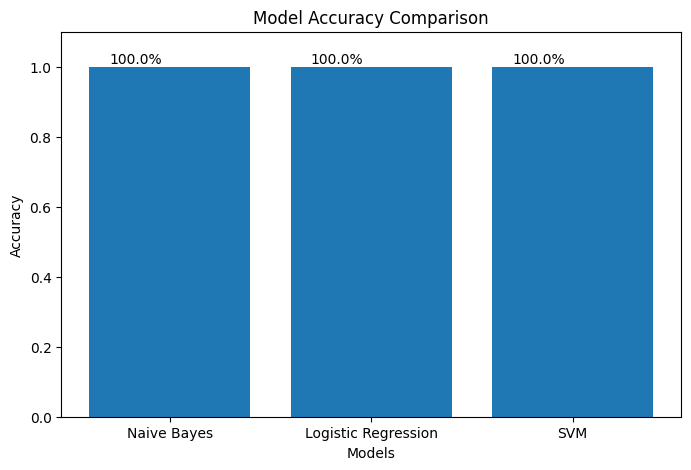

In [10]:
import pandas as pd
import nltk
import re
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

nltk.download('stopwords')
from nltk.corpus import stopwords

df = pd.read_csv("/content/email_dataset_200 (1).csv")

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

df['text'] = df['text'].apply(clean_text)

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['text'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = []
accuracies = []


nb = MultinomialNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, pred_nb)

models.append("Naive Bayes")
accuracies.append(acc_nb)

param_lr = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(LogisticRegression(), param_lr, cv=3)
grid_lr.fit(X_train, y_train)

pred_lr = grid_lr.predict(X_test)
acc_lr = accuracy_score(y_test, pred_lr)

models.append("Logistic Regression")
accuracies.append(acc_lr)


param_svm = {
    'C': [0.1, 1, 10],
    'loss': ['hinge', 'squared_hinge']
}

grid_svm = GridSearchCV(LinearSVC(), param_svm, cv=3)
grid_svm.fit(X_train, y_train)

pred_svm = grid_svm.predict(X_test)
acc_svm = accuracy_score(y_test, pred_svm)

models.append("SVM")
accuracies.append(acc_svm)

print("\nModel Accuracy Results:\n")

for m, a in zip(models, accuracies):
    print(m, ":", round(a * 100, 2), "%")

best_index = accuracies.index(max(accuracies))

if best_index == 0:
    best_model = nb
elif best_index == 1:
    best_model = grid_lr
else:
    best_model = grid_svm

joblib.dump(best_model, "best_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

print("\nModel Saved Successfully!")


plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+0.1, y+0.01, str(round(y*100,2))+"%")

plt.ylim(0,1.1)
plt.show()

In [12]:
baseline_model = LogisticRegression()
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_pred)

param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear']
}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=3)
grid.fit(X_train, y_train)

tuned_pred = grid.predict(X_test)
tuned_acc = accuracy_score(y_test, tuned_pred)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", round(grid.best_score_ * 100, 2), "%")

print("\nBefore Tuning Accuracy:", round(baseline_acc * 100, 2), "%")
print("After Tuning Accuracy:", round(tuned_acc * 100, 2), "%")

Best Parameters: {'C': 0.1, 'solver': 'liblinear'}
Best Accuracy: 100.0 %

Before Tuning Accuracy: 100.0 %
After Tuning Accuracy: 100.0 %


In [11]:
model = joblib.load("best_model.pkl")
vectorizer = joblib.load("vectorizer.pkl")


text = input("\nEnter Email/Text Message: ")


cleaned = clean_text(text)

data = vectorizer.transform([cleaned])

prediction = model.predict(data)[0]

print("\nPrediction:", prediction.upper())

if prediction == "spam":
    print("This message is SPAM")
else:
    print("This message is HAM / Normal Message")


Enter Email/Text Message: hi

Prediction: HAM
This message is HAM / Normal Message
